# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

# 图像特征练习
*请将完成后的这份工作表（包括其输出以及工作表外的任何支持代码）与你的作业提交一起提交。更多详情请参阅课程网站上的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)*。

我们已知通过在输入图像的像素上训练线性分类器，可以在图像分类任务中实现合理的性能。在这个练习中，我们将展示通过训练线性分类器不是在原始像素上，而是在从原始像素计算出的特征上，可以提升我们的分类性能。

你所有关于这个练习的工作都将在本笔记本中完成。

In [1]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [3]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

/home/x1879/cs231n/assignment1/cs231n/data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

## 提取特征
对于每张图像，我们将计算其方向梯度直方图（HOG）以及使用HSV颜色空间中的色调通道的颜色直方图。我们将每个图像的最终特征向量通过连接HOG和颜色直方图特征向量来形成。

粗略地说，HOG应该能够捕捉图像的纹理信息，同时忽略颜色信息，而颜色直方图则代表输入图像的颜色，同时忽略纹理信息。因此，我们预期使用两者结合应该会比单独使用其中任何一个效果更好。验证这个假设是一个值得尝试的好主意。

`hog_feature` 和 `color_histogram_hsv` 函数都作用于单个图像，并返回该图像的特征向量。`extract_features` 函数接受一组图像和一组特征函数，并对每个图像上的每个特征函数进行评估，将结果存储在一个矩阵中，其中每一列是单个图像所有特征向量的连接。

In [4]:
from cs231n.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

In [18]:
X_train_feats

array([[ 0.3542173 , -0.17205266, -0.1893237 , ..., -0.46472025,
        -0.43590773,  1.        ],
       [ 0.60864031,  0.1855667 , -0.11373096, ..., -0.13043821,
        -0.22598018,  1.        ],
       [-0.61089678, -0.7156692 , -0.69093406, ..., -0.04686771,
         0.17479058,  1.        ],
       ...,
       [-0.67469848, -0.07675098,  0.12264094, ..., -0.46472025,
        -0.45499205,  1.        ],
       [-0.66647831, -0.32264783, -0.69848389, ...,  0.17598698,
         1.47252447,  1.        ],
       [-0.20583649, -0.54116807, -0.55268827, ...,  1.68025615,
         0.88091049,  1.        ]], shape=(49000, 170))

## Train Softmax classifier on features
Using the Softmax code developed earlier in the assignment, train Softmax classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.

## 在提取的特征上训练Softmax分类器
使用在作业中早期开发的Softmax代码，在上述提取的特征上训练Softmax分类器；这应该比直接在原始像素上训练它们获得更好的结果。

In [13]:
# Use the validation set to tune the learning rate and regularization strength

from cs231n.classifiers.linear_classifier import Softmax

learning_rates = [1e-7, 1e-6]
regularization_strengths = [5e5, 5e6]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the Softmax; save#
# the best trained classifer in best_softmax. If you carefully tune the model, #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################


for lr in learning_rates:
    for reg in regularization_strengths:
        sm=Softmax()
        loss_hist=sm.train(X_train_feats,y_train,lr,reg,1500)

        y_train_pred=sm.predict(X_train_feats)
        train_accuracy=np.mean(y_train==y_train_pred)

        y_val_pred=sm.predict(X_val_feats)
        val_accuracy=np.mean(y_val_pred==y_val)
        
        if val_accuracy>best_val:
            best_val=val_accuracy
            best_softmax=sm
        
        results[(lr,reg)]=(train_accuracy,val_accuracy)


# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved: %f' % best_val)

lr 1.000000e-07 reg 5.000000e+05 train accuracy: 0.410122 val accuracy: 0.431000
lr 1.000000e-07 reg 5.000000e+06 train accuracy: 0.318612 val accuracy: 0.311000
lr 1.000000e-06 reg 5.000000e+05 train accuracy: 0.332980 val accuracy: 0.339000
lr 1.000000e-06 reg 5.000000e+06 train accuracy: 0.100265 val accuracy: 0.087000
best validation accuracy achieved: 0.431000


In [7]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.424


In [8]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


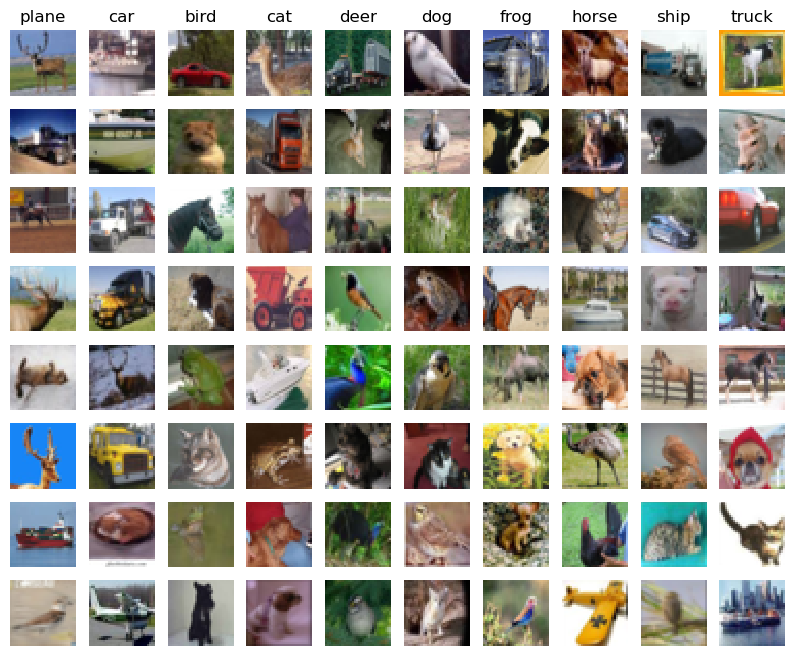

In [9]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textit Your Answer:错分类的图片通常具有某些其他图片的特征，如被错分类为飞机的图片往往具有白色或蓝色的背景}$





## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [ ]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(Iteration 1 / 9800) loss: 2.302568
(Epoch 0 / 40) train acc: 0.107000; val_acc: 0.107000
(Iteration 101 / 9800) loss: 2.200536
(Iteration 201 / 9800) loss: 1.662624
(Epoch 1 / 40) train acc: 0.440000; val_acc: 0.412000
(Iteration 301 / 9800) loss: 1.652935
(Iteration 401 / 9800) loss: 1.497692
(Epoch 2 / 40) train acc: 0.508000; val_acc: 0.511000
(Iteration 501 / 9800) loss: 1.281522
(Iteration 601 / 9800) loss: 1.391573
(Iteration 701 / 9800) loss: 1.166163
(Epoch 3 / 40) train acc: 0.512000; val_acc: 0.506000
(Iteration 801 / 9800) loss: 1.359171
(Iteration 901 / 9800) loss: 1.332590
(Epoch 4 / 40) train acc: 0.551000; val_acc: 0.532000
(Iteration 1001 / 9800) loss: 1.247833
(Iteration 1101 / 9800) loss: 1.222427
(Iteration 1201 / 9800) loss: 1.188802
(Epoch 5 / 40) train acc: 0.555000; val_acc: 0.548000
(Iteration 1301 / 9800) loss: 1.265469
(Iteration 1401 / 9800) loss: 1.275874
(Epoch 6 / 40) train acc: 0.543000; val_acc: 0.536000
(Iteration 1501 / 9800) loss: 1.136761
(Iteration

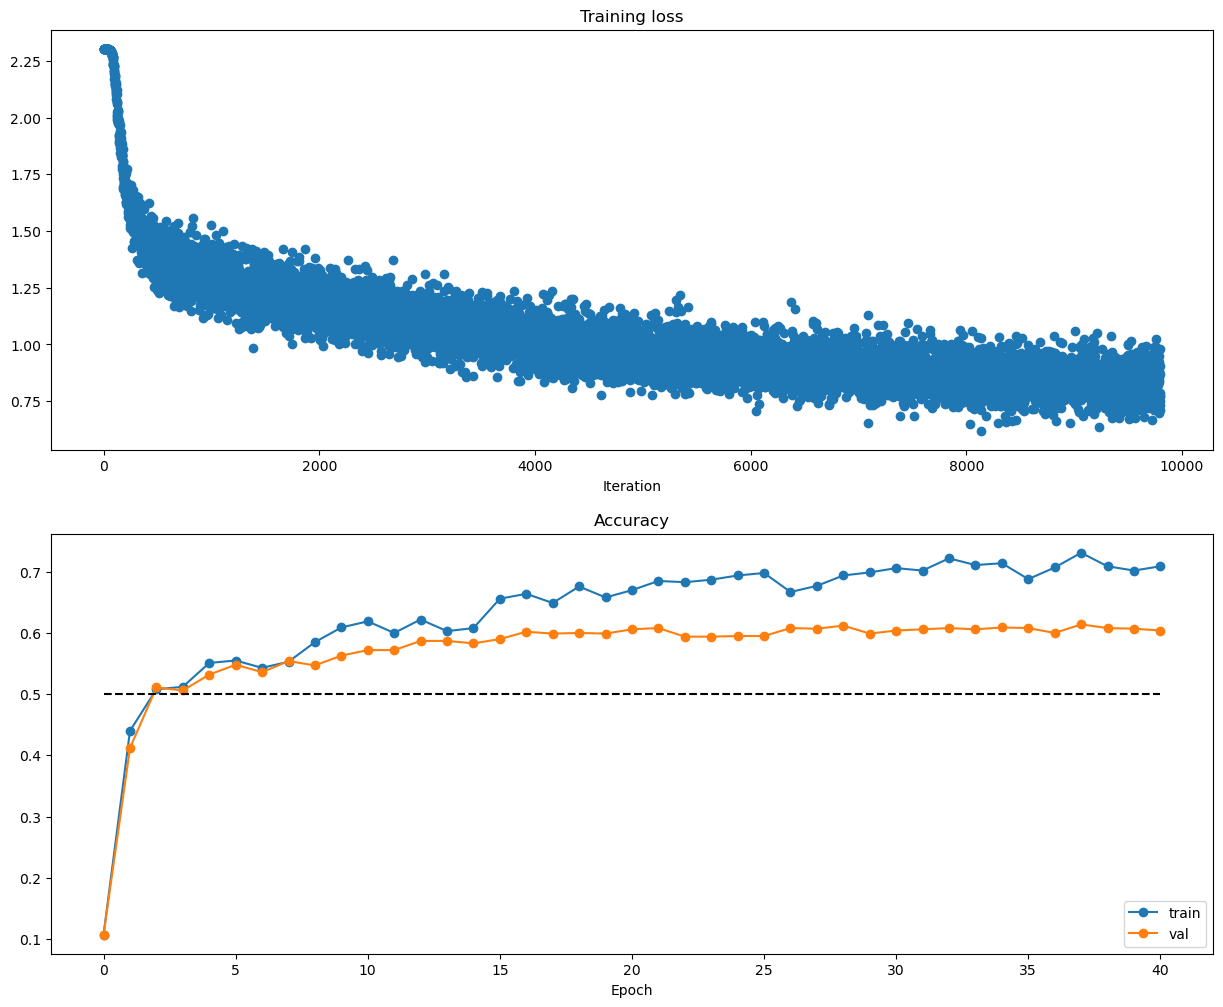

(Iteration 1 / 9800) loss: 2.302545
(Epoch 0 / 40) train acc: 0.096000; val_acc: 0.119000
(Iteration 101 / 9800) loss: 1.525943
(Iteration 201 / 9800) loss: 1.579045
(Epoch 1 / 40) train acc: 0.477000; val_acc: 0.510000
(Iteration 301 / 9800) loss: 1.349942
(Iteration 401 / 9800) loss: 1.248961
(Epoch 2 / 40) train acc: 0.530000; val_acc: 0.536000
(Iteration 501 / 9800) loss: 1.282634
(Iteration 601 / 9800) loss: 1.321672
(Iteration 701 / 9800) loss: 1.079553
(Epoch 3 / 40) train acc: 0.567000; val_acc: 0.541000
(Iteration 801 / 9800) loss: 1.261273
(Iteration 901 / 9800) loss: 1.142833
(Epoch 4 / 40) train acc: 0.630000; val_acc: 0.573000
(Iteration 1001 / 9800) loss: 1.062495
(Iteration 1101 / 9800) loss: 0.977950
(Iteration 1201 / 9800) loss: 1.087636
(Epoch 5 / 40) train acc: 0.637000; val_acc: 0.590000
(Iteration 1301 / 9800) loss: 0.997165
(Iteration 1401 / 9800) loss: 0.979161
(Epoch 6 / 40) train acc: 0.651000; val_acc: 0.591000
(Iteration 1501 / 9800) loss: 1.035605
(Iteration

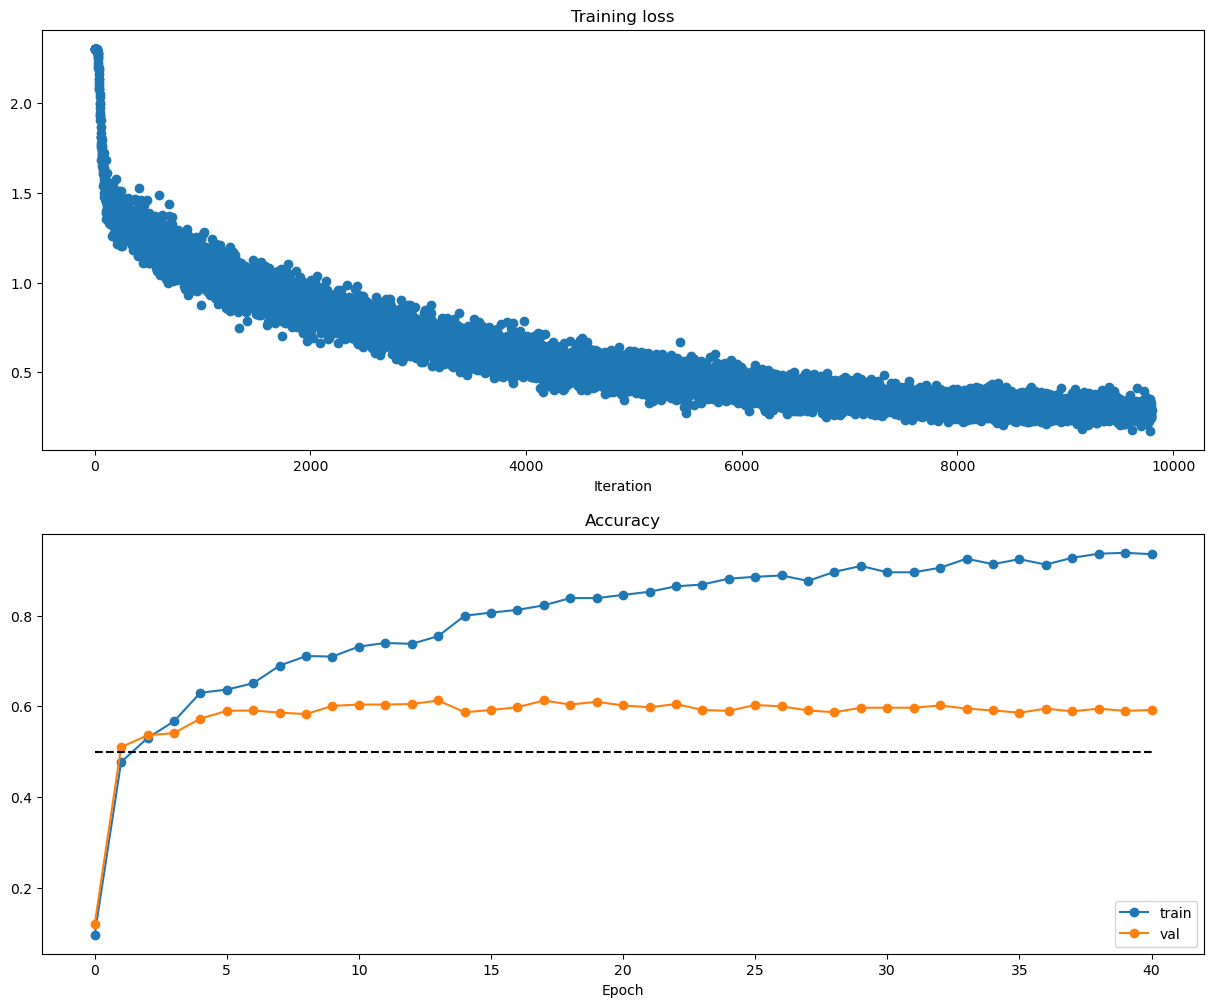

In [21]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val': X_val_feats,
    'y_val': y_val,
    'X_test': X_test_feats,
    'y_test': y_test,
}


best_net = None
best_acc = -1
learning_rates = [1e-1,3e-1]
################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################
for lr in learning_rates:
    net = TwoLayerNet(input_dim, hidden_dim, num_classes)
    solver = Solver(net, data,
                update_rule='sgd',
                optim_config={
                'learning_rate': lr,
                },
                lr_decay=0.95,
                num_epochs=40, batch_size=200,
                print_every=100)
    solver.train()
    y_val_pred = np.argmax(net.loss(data['X_val']), axis=1)
    val_acc = (y_test_pred == data['y_val']).mean()
    if val_acc > best_acc:
        best_net=net
    plt.subplot(2, 1, 1)
    plt.title('Training loss')
    plt.plot(solver.loss_history, 'o')
    plt.xlabel('Iteration')

    plt.subplot(2, 1, 2)
    plt.title('Accuracy')
    plt.plot(solver.train_acc_history, '-o', label='train')
    plt.plot(solver.val_acc_history, '-o', label='val')
    plt.plot([0.5] * len(solver.val_acc_history), 'k--')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.gcf().set_size_inches(15, 12)
    plt.show()



In [22]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.59


In [23]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.


In [4]:
for i in range(4,0,-1):
    print(i)

4
3
2
1
